In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d grassknoted/asl-alphabet
!unzip asl-alphabet.zip -d asl_alphabet_train

Streaming output truncated to the last 5000 lines.
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing19.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing190.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1900.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1901.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1902.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1903.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1904.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1905.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing1906.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/asl_alphabet_train/nothing/nothing190

In [ ]:
import pandas as pd
df = pd.read_csv("asl_preprocessed_sample.csv")
print(df.shape)
print(df.head())

(2600, 4099)
  label  label_encoded  split  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  \
0     S             18  train  0.21569  0.24706  0.26275  0.26275  0.25490   
1     H              7  train  0.21176  0.25490  0.27059  0.27451  0.27451   
2     P             15  train  0.23529  0.27059  0.29412  0.29804  0.29020   
3     Y             24   test  0.23922  0.27843  0.30196  0.30588  0.31373   
4     S             18  train  0.26275  0.30980  0.34118  0.34510  0.34510   

   pixel_6  pixel_7  ...  pixel_4087  pixel_4088  pixel_4089  pixel_4090  \
0  0.24706  0.23529  ...     0.38824     0.38824     0.38431     0.38039   
1  0.27059  0.27059  ...     0.38039     0.38431     0.38039     0.38039   
2  0.29804  0.30588  ...     0.40784     0.41176     0.40784     0.40784   
3  0.32941  0.35294  ...     0.44314     0.48235     0.51765     0.54902   
4  0.35294  0.36471  ...     0.43529     0.43529     0.43922     0.43529   

   pixel_4091  pixel_4092  pixel_4093  pixel_4094  pixel_4095

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance
import random
import cv2
from rembg import remove  # pip install rembg
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
DATASET_PATH = "asl_alphabet_train/asl_alphabet_train/asl_alphabet_train"
OUTPUT_CSV   = "asl_preprocessed_with_bg_removal.csv"
IMG_SIZE     = 64
SAMPLES_PER_CLASS = 3000
RANDOM_SEED  = 42
TEST_RATIO   = 0.2
AUGMENT_TRAINING = True  # Apply augmentation to training images only

CLASSES = [
    'A','B','C','D','E','F','G','H','I','J','K','L','M',
    'N','O','P','Q','R','S','T','U','V','W','X','Y','Z',
    'SPACE','DELETE','NOTHING'
]

# ============================================================================
# AUGMENTATION FUNCTIONS
# ============================================================================
def augment_image(img):
    """Apply random transformations to simulate real-world conditions"""

    # Random brightness (±20%)
    if random.random() > 0.5:
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Random contrast (±20%)
    if random.random() > 0.5:
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Random rotation (±15 degrees)
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        img = img.rotate(angle, fillcolor=(255, 255, 255), expand=False)

    # Random horizontal flip (50% chance) - careful with letters!
    # Disabled for ASL since letters aren't symmetric
    # if random.random() > 0.5:
    #     img = img.transpose(Image.FLIP_LEFT_RIGHT)

    return img

# ============================================================================
# PREPROCESSING FUNCTION WITH BACKGROUND REMOVAL
# ============================================================================
def preprocess_image(img_path, is_training=False):
    """
    Preprocess image with background removal and optional augmentation.

    Args:
        img_path: Path to the image file
        is_training: If True, apply augmentation

    Returns:
        Flattened numpy array of normalized pixel values, or None if error
    """
    try:
        # Step 1: Load image
        img = Image.open(img_path).convert("RGB")

        # Step 2: Remove background using rembg
        # This creates an image with transparent background
        img_no_bg = remove(img)

        # Step 3: Replace transparent background with white
        # Create white background
        white_bg = Image.new("RGB", img_no_bg.size, (255, 255, 255))

        # Paste the image with no background onto white background
        # Use alpha channel as mask
        if img_no_bg.mode == 'RGBA':
            white_bg.paste(img_no_bg, mask=img_no_bg.split()[3])
        else:
            white_bg.paste(img_no_bg)

        # Step 4: Apply augmentation (only for training images)
        if is_training and AUGMENT_TRAINING:
            white_bg = augment_image(white_bg)

        # Step 5: Resize to target size
        img = white_bg.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

        # Step 6: Convert to grayscale
        img = img.convert("L")

        # Step 7: Apply edge enhancement before blur
        # This helps preserve finger boundaries
        img = img.filter(ImageFilter.EDGE_ENHANCE_MORE)

        # Step 8: Apply slight Gaussian blur to reduce noise
        img = img.filter(ImageFilter.GaussianBlur(radius=0.5))

        # Step 9: Convert to numpy array and normalize to [0, 1]
        arr = np.array(img, dtype=np.float32) / 255.0

        # Step 10: Flatten to 1D array
        return arr.flatten()

    except Exception as e:
        print(f"  [ERROR] {img_path}: {e}")
        return None

# ============================================================================
# MAIN PROCESSING LOOP
# ============================================================================
def main():
    print("=" * 70)
    print("ASL ALPHABET PREPROCESSING WITH BACKGROUND REMOVAL")
    print("=" * 70)
    print(f"Dataset path: {DATASET_PATH}")
    print(f"Output CSV: {OUTPUT_CSV}")
    print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
    print(f"Samples per class: {SAMPLES_PER_CLASS}")
    print(f"Test ratio: {TEST_RATIO}")
    print(f"Augmentation: {AUGMENT_TRAINING}")
    print("=" * 70)

    # Define pixel column names
    pixel_cols = [f"pixel_{i}" for i in range(1, IMG_SIZE * IMG_SIZE + 1)]

    # Set random seed for reproducibility
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # Track whether this is the first class (for CSV header)
    first_class = True

    # Process each class
    for label_encoded, class_name in enumerate(CLASSES):
        class_folder = os.path.join(DATASET_PATH, class_name)

        # Check if folder exists
        if not os.path.isdir(class_folder):
            print(f"[MISSING] {class_name} folder not found — skipping")
            continue

        # Get all image files in the folder
        image_files = [
            f for f in os.listdir(class_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        # Limit to SAMPLES_PER_CLASS
        image_files = image_files[:SAMPLES_PER_CLASS]

        # Shuffle for random train/test split
        random.shuffle(image_files)

        # Calculate split index
        split_index = int(len(image_files) * (1 - TEST_RATIO))

        print(f"\n[{label_encoded + 1}/{len(CLASSES)}] Processing {class_name}...")
        print(f"  Total images: {len(image_files)}")
        print(f"  Train: {split_index}, Test: {len(image_files) - split_index}")

        # Process each image
        rows = []
        for i, fname in enumerate(image_files):
            img_path = os.path.join(class_folder, fname)
            is_training = (i < split_index)

            # Preprocess image
            pixels = preprocess_image(img_path, is_training=is_training)

            if pixels is not None:
                # Determine split
                split = "train" if is_training else "test"

                # Create row
                row = {
                    "label": class_name,
                    "label_encoded": label_encoded,
                    "split": split
                }

                # Add pixel values
                for j, val in enumerate(pixels, start=1):
                    row[f"pixel_{j}"] = round(float(val), 5)

                rows.append(row)

            # Progress indicator
            if (i + 1) % 100 == 0:
                print(f"    Processed {i + 1}/{len(image_files)} images...")

        # Create DataFrame for this class
        df_class = pd.DataFrame(rows)

        # Ensure column order
        df_class = df_class[["label", "label_encoded", "split"] + pixel_cols]

        # Append to CSV
        df_class.to_csv(
            OUTPUT_CSV,
            mode='w' if first_class else 'a',
            header=first_class,
            index=False
        )

        print(f"  ✓ Saved {len(df_class)} rows to CSV")
        first_class = False

    print("\n" + "=" * 70)
    print("PREPROCESSING COMPLETE!")
    print("=" * 70)

    # Load and display summary statistics
    df = pd.read_csv(OUTPUT_CSV)
    print(f"\nTotal rows: {len(df)}")
    print(f"\nTrain/Test split:")
    print(df['split'].value_counts())
    print(f"\nClass distribution:")
    print(df['label'].value_counts().sort_index())
    print(f"\nCSV file size: {os.path.getsize(OUTPUT_CSV) / (1024**2):.2f} MB")
    print("\nReady for model training!")

# ============================================================================
# RUN SCRIPT
# ============================================================================
if __name__ == "__main__":
    main()

Processing A (3000 images)...
  Saved 3000 rows
Processing B (3000 images)...
  Saved 3000 rows
Processing C (3000 images)...
  Saved 3000 rows
Processing D (3000 images)...
  Saved 3000 rows
Processing E (3000 images)...
  Saved 3000 rows
Processing F (3000 images)...
  Saved 3000 rows
Processing G (3000 images)...
  Saved 3000 rows
Processing H (3000 images)...
  Saved 3000 rows
Processing I (3000 images)...
  Saved 3000 rows
Processing J (3000 images)...
  Saved 3000 rows
Processing K (3000 images)...
  Saved 3000 rows
Processing L (3000 images)...
  Saved 3000 rows
Processing M (3000 images)...
  Saved 3000 rows
Processing N (3000 images)...
  Saved 3000 rows
Processing O (3000 images)...
  Saved 3000 rows
Processing P (3000 images)...
  Saved 3000 rows
Processing Q (3000 images)...
  Saved 3000 rows
Processing R (3000 images)...
  Saved 3000 rows
Processing S (3000 images)...
  Saved 3000 rows
Processing T (3000 images)...
  Saved 3000 rows
Processing U (3000 images)...
  Saved 30

In [ ]:
import pandas as pd
df = pd.read_csv("asl_preprocessed_sample.csv")
print(df.shape)
print(df['label'].value_counts())

(78000, 4099)
label
A    3000
B    3000
C    3000
D    3000
E    3000
F    3000
G    3000
H    3000
I    3000
J    3000
K    3000
L    3000
M    3000
N    3000
O    3000
P    3000
Q    3000
R    3000
S    3000
T    3000
U    3000
V    3000
W    3000
X    3000
Y    3000
Z    3000
Name: count, dtype: int64


In [ ]:
import shutil
shutil.copy("asl_preprocessed_sample.csv", "/content/drive/MyDrive/asl_preprocessed_sample.csv")
print("Saved to Drive!")

Saved to Drive!


In [ ]:
import pandas as pd
import numpy as np

# Load the CSV
df = pd.read_csv("/content/drive/MyDrive/asl_preprocessed_sample.csv")

# Extract pixel columns into X
pixel_cols = [col for col in df.columns if col.startswith("pixel_")]
X = df[pixel_cols].values  # shape: (78000, 4096)

# Extract labels into y
y = df["label_encoded"].values  # shape: (78000,)

# Check pixel values are between 0 and 1
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

# Reshape X from (78000, 4096) into (78000, 64, 64, 1)
# 64x64 is the image size, 1 is for grayscale channel
X = X.reshape(-1, 64, 64, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

Min pixel value: 0.00392
Max pixel value: 0.99608
X shape: (78000, 64, 64, 1)
y shape: (78000,)


In [ ]:
#Get indices where split column is "train" and "test"
train_mask = df["split"] == "train"
test_mask = df["split"] == "test"

#Separate X and y into train and test
X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (62400, 64, 64, 1)
X_test shape: (15600, 64, 64, 1)
y_train shape: (62400,)
y_test shape: (15600,)


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load only the columns we need
df = pd.read_csv("/content/drive/MyDrive/asl_preprocessed_sample.csv")

# Separate train and test first
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

# Free up memory immediately
del df

pixel_cols = [col for col in train_df.columns if col.startswith("pixel_")]

# Extract and reshape train
X_train = train_df[pixel_cols].values.reshape(-1, 64, 64, 1)
y_train = train_df["label_encoded"].values
del train_df  # free RAM immediately after

# Extract and reshape test
X_test = test_df[pixel_cols].values.reshape(-1, 64, 64, 1)
y_test = test_df["label_encoded"].values
del test_df  # free RAM immediately after

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Augmentation
augment = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)
augment.fit(X_train)
print("Augmentation ready!")

X_train shape: (62400, 64, 64, 1)
X_test shape: (15600, 64, 64, 1)
Augmentation ready!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First convolutional block
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2, 2),

    # Second convolutional block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flatten and classify
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(26, activation='softmax')  # 26 classes (A-Z)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,930 (6.21 MB)

 Trainable params: 1,627,930 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    augment.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1
)

# Save the model
model.save("model_person1.h5")
print("Model saved!")

Epoch 1/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 452s 230ms/step - accuracy: 0.3042 - loss: 2.2363 - val_accuracy: 0.6399 - val_loss: 1.2041
Epoch 2/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 459s 236ms/step - accuracy: 0.5026 - loss: 1.4842 - val_accuracy: 0.7610 - val_loss: 0.7932
Epoch 3/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 440s 225ms/step - accuracy: 0.5812 - loss: 1.2183 - val_accuracy: 0.8385 - val_loss: 0.5613
Epoch 4/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 468s 240ms/step - accuracy: 0.6346 - loss: 1.0535 - val_accuracy: 0.8701 - val_loss: 0.4530
Epoch 5/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 499s 239ms/step - accuracy: 0.6696 - loss: 0.9439 - val_accuracy: 0.8675 - val_loss: 0.4038
Epoch 6/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 442s 227ms/step - accuracy: 0.6972 - loss: 0.8624 - val_accuracy: 0.9187 - val_loss: 0.3035
Epoch 7/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 476s 244ms/step - accuracy: 0.7194 - loss: 0.7929 - val_accuracy: 0.9283 - val_loss: 0.2629
Epoch 8/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 459s 235ms/step - ac

Model saved!


In [ ]:
import shutil
shutil.copy("model_person1.h5", "/content/drive/MyDrive/model_person1.h5")
print("Model saved to Drive!")

Model saved to Drive!


In [ ]:
import numpy as np

# Save arrays as .npy files
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)
print("Arrays saved!")

# Copy to Drive
import shutil
shutil.copy("X_train.npy", "/content/drive/MyDrive/X_train.npy")
shutil.copy("X_test.npy", "/content/drive/MyDrive/X_test.npy")
shutil.copy("y_train.npy", "/content/drive/MyDrive/y_train.npy")
shutil.copy("y_test.npy", "/content/drive/MyDrive/y_test.npy")
print("All copied to Drive!")

Arrays saved!
All copied to Drive!


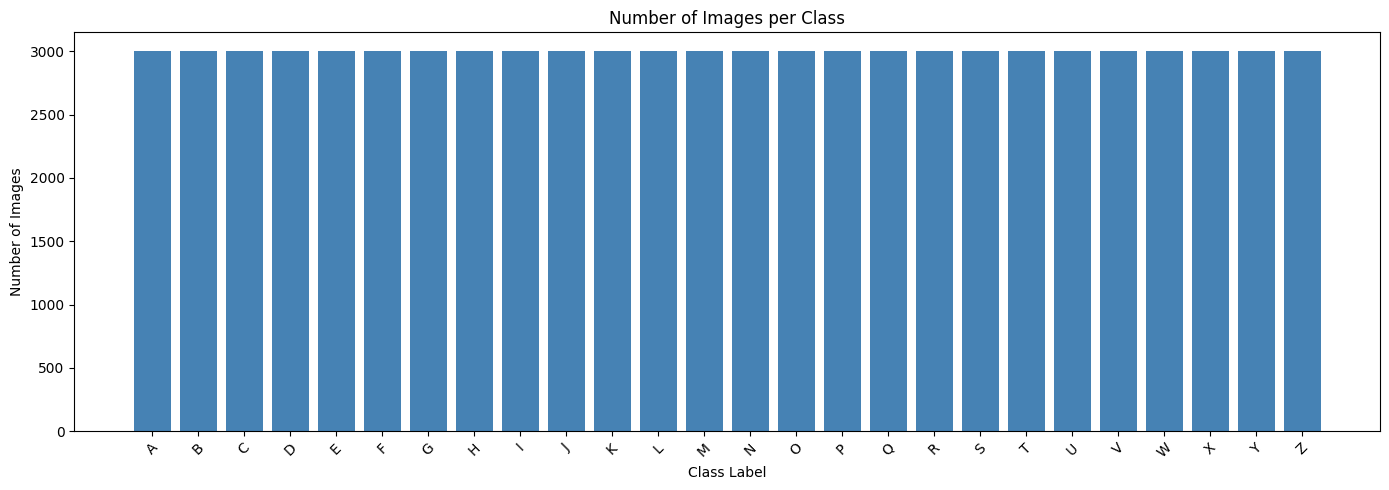

Done!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_labels = pd.read_csv("/content/asl_preprocessed_sample.csv", usecols=["label"])

label_counts = df_labels["label"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue')
plt.title("Number of Images per Class")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("viz1_class_distribution.png")
plt.show()
print("Done!")

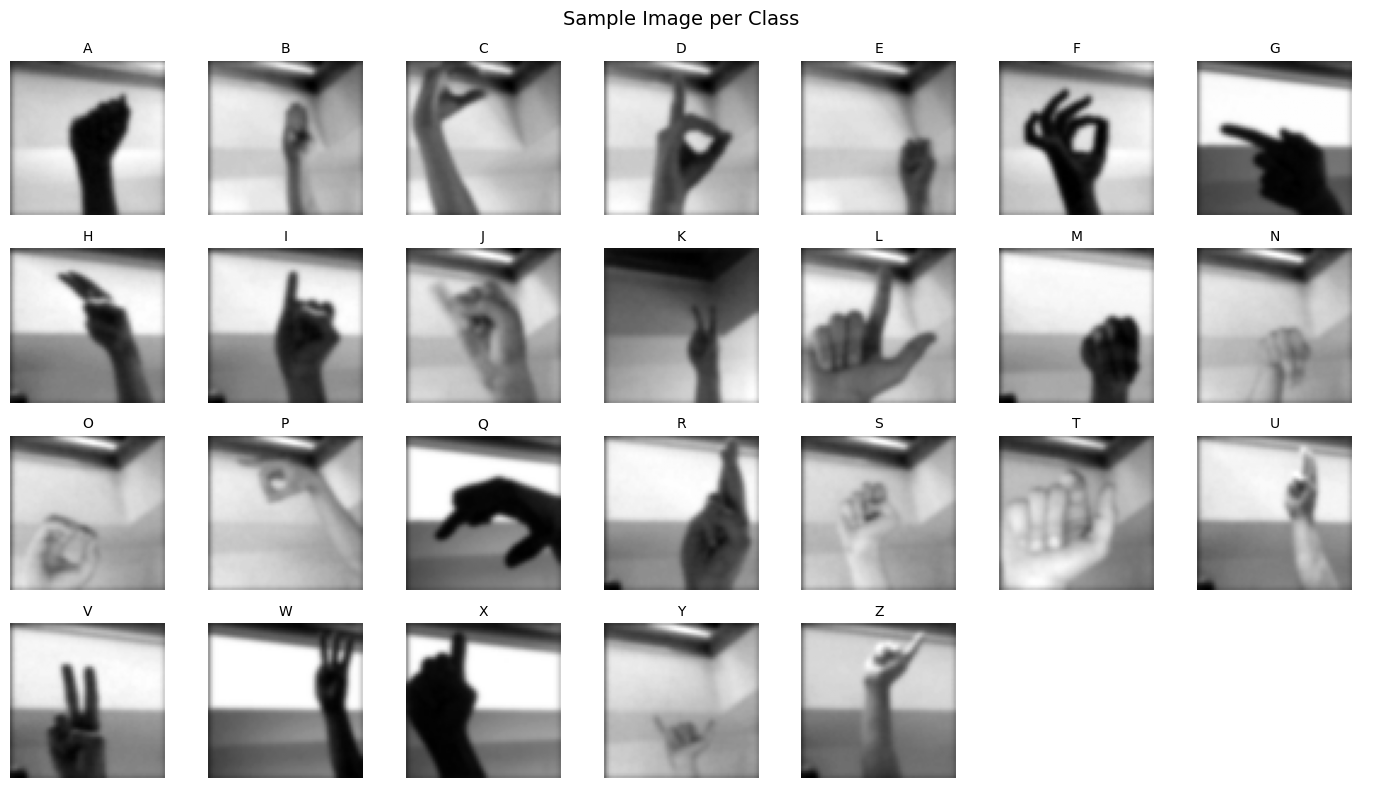

Done!


In [ ]:
import matplotlib.pyplot as plt

classes = sorted(set(y_train))
class_names = [chr(65 + i) for i in range(26)]

fig, axes = plt.subplots(4, 7, figsize=(14, 8))
axes = axes.flatten()

for i, class_id in enumerate(classes):
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(64, 64)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(class_names[i], fontsize=10)
    axes[i].axis("off")

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Image per Class", fontsize=14)
plt.tight_layout()
plt.savefig("viz2_sample_images.png")
plt.show()
print("Done!")

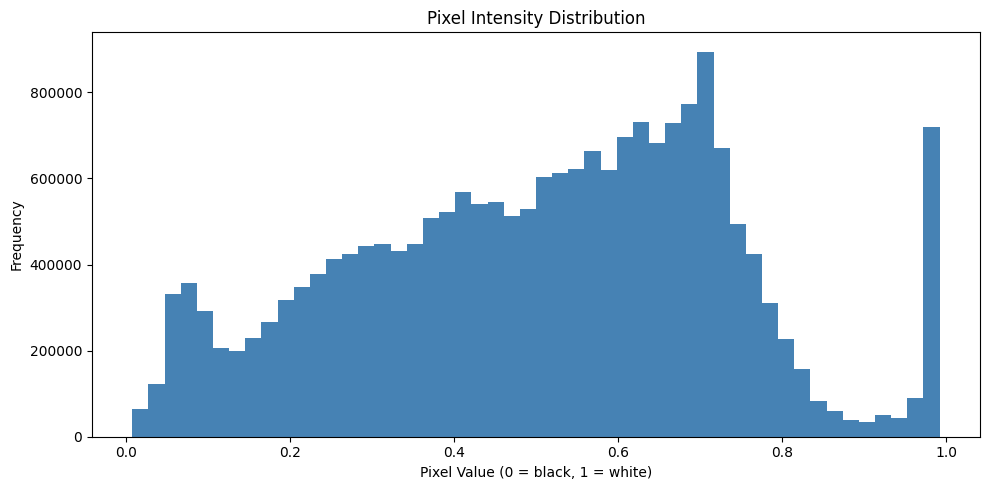

Done!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sample 5000 random images to avoid RAM issues
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
sample_pixels = X_train[sample_idx].flatten()

plt.figure(figsize=(10, 5))
plt.hist(sample_pixels, bins=50, color='steelblue', edgecolor='none')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value (0 = black, 1 = white)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("viz3_pixel_histogram.png")
plt.show()
print("Done!")

In [ ]:
import shutil
shutil.copy("viz1_class_distribution.png", "/content/drive/MyDrive/viz1_class_distribution.png")
shutil.copy("viz2_sample_images.png", "/content/drive/MyDrive/viz2_sample_images.png")
shutil.copy("viz3_pixel_histogram.png", "/content/drive/MyDrive/viz3_pixel_histogram.png")
print("All visualizations saved to Drive!")

All visualizations saved to Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("/content/drive/MyDrive/model_person1.h5", "/content/model_person1.h5")
shutil.copy("/content/drive/MyDrive/X_test.npy", "/content/X_test.npy")
shutil.copy("/content/drive/MyDrive/y_test.npy", "/content/y_test.npy")
print("Files ready!")


Mounted at /content/drive
Files ready!


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow import keras

model = keras.models.load_model('model_person1.h5')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

predictions = model.predict(X_test)
y_pred = predictions.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

488/488 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step
Accuracy:  96.99%
Precision: 97.03%
Recall:    96.99%
F1 Score:  96.99%
